In [1]:
using Pkg
Pkg.activate("./../julia-code")

  Activating project at `~/code/compositional/julia-code`


In [2]:
using Meris
using DataFrames, DataFramesMeta, StatsBase, Distributions, LsqFit
using CairoMakie, ColorSchemes, MakiePublication, LaTeXStrings
using Optim, SpecialFunctions, Random

In [3]:
# import dataset
arXiv_df =  Meris.arXivSampler.collect_arXive(stopwords=false);
# bci_df = Meris.BCITreeSampler.load_treedata(; joinquadrats=true, steps=1);
# lego_df = Meris.LegoSampler.parse_themes(; returnthemes=false);

In [4]:
df = deepcopy(arXiv_df)
df.class = df.domain .* df.topic
select!(df, Not(:domain, :topic))
first(df, 5)

Row,component_id,sample_id,counts,nreads,class
,String,Int64,Int64,Int64,String
1,newly,1,4,4815,physicssoc-ph
2,step,1,9,4815,physicssoc-ph
3,attack,1,1,4815,physicssoc-ph
4,zhuang,1,1,4815,physicssoc-ph
5,figure,1,1,4815,physicssoc-ph


### HYP1: Component's distribution is power-law within a document
If this is true, it may indicate that generation of a single document is done through a Pitman-Yor process.

In [5]:
sdf = @chain df begin
    
    @groupby(:class, :component_id)
    @combine(
        :sample_id,
        :counts,
        :nreads,
        :presence = length(:sample_id)
    )
    
    @groupby(:class)
    @transform(:total_samples = length(unique(:sample_id)))
    @transform(:occupancy = :presence ./ :total_samples)

    @groupby(:sample_id, :class)
    @combine(
        :component_id,
        :counts,
        :ranks = tiedrank(-:counts),
        :nreads,
        :vocab_size = length(unique(:component_id)),
        :occupancy
    )
end

first(sdf, 5)

Row,sample_id,class,component_id,counts,ranks,nreads,vocab_size,occupancy
,Int64,String,String,Int64,Float64,Int64,Int64,Float64
1,1,physicssoc-ph,newly,4,147.0,4815,788,0.126984
2,1,physicssoc-ph,step,9,53.5,4815,788,0.714286
3,1,physicssoc-ph,attack,1,591.0,4815,788,0.0952381
4,1,physicssoc-ph,zhuang,1,591.0,4815,788,0.0031746
5,1,physicssoc-ph,figure,1,591.0,4815,788,0.701587


### HYP2: Heap's law is satisfied for a set of documents of the same type
If it is true then the generating process might be the Pitman-Yor or the Gerlach process. In particular, if Heap's law is found to hold with double scaling then the simple Pitman_Yor is excluded.

In [3]:
# Collect arXiv papers into a Dictionary preserving data structure: domain -> topic -> document
DIR = Meris.ARXIVDIR * "clean_text/"
domains = Dict{String,Dict{String,Vector{Vector{String}}}}()

for domain_dir in filter(isdir, readdir(DIR; join=true))
    domain = splitpath(domain_dir)[end]
    topic_map = Dict{String,Vector{Vector{String}}}()

    for topic_dir in filter(isdir, readdir(domain_dir; join=true))
        topic = splitpath(topic_dir)[end]

        txt_files = filter(f -> endswith(f, ".txt"), readdir(topic_dir; join=true))
        if isempty(txt_files)
            continue
        end

        topic_map[topic] = [readlines(f) for f in txt_files]
    end

    if !isempty(topic_map)
        domains[domain] = topic_map
    end
end

In [4]:
# Merge all documents into a single array of words
words_array = []
for (d, topic) in domains
    for (t, doc) in topic
        append!(words_array, doc...)
    end
end

# remove stopwords
filter!(x -> x ∉ Meris.arXivSampler.STOPWORDS, words_array);

In [5]:
# Merge all documents into a single array of words
domain_words_dict = Dict()
for (d, topic) in domains
    domain_words_dict[d] = []
    for (t, doc) in topic
        append!(domain_words_dict[d], doc...)
    end
    # remove stopwords
    filter!(x -> x ∉ Meris.arXivSampler.STOPWORDS, domain_words_dict[d])
end

In [6]:
log_indices = collect(log10(1):0.1:log10(length(words_array)))
log_indices = unique(floor.(Int, 10 .^ log_indices))
heap_dict_total = sort(Dict(idx => length(unique(words_array[1:idx])) for idx in log_indices))
heap_dict_domains = Dict()

for (d, arr) in domain_words_dict
    log_indices = collect(log10(1):0.1:log10(length(arr)))
    log_indices = unique(floor.(Int, 10 .^ log_indices))
    heap_dict_domains[d] = sort(Dict(idx => length(unique(arr[1:idx])) for idx in log_indices))
end

In [7]:
function find_breakpoint(model1, model2, x, y, p10, p20; scanrange=nothing, grain=10, cl=0.1)
    scanrange = isnothing(scanrange) ? collect(minimum(x)+grain:grain:maximum(x)) : scanrange
    logx = log.(x)
    logy = log.(y)
    SSE, xb, p1, p2 = Inf, NaN, NaN, NaN
    for xi in scanrange
        mask = x .< xi
        logx1, logy1 = logx[mask], logy[mask]
        logx2, logy2 = logx[.!mask], logy[.!mask]
        fit1 = curve_fit(model1, logx1, logy1, p10)
        fit2 = curve_fit(model2, logx2, logy2, p20)
        res1 = sum((logy1 .- model1(logx1, fit1.param)) .^ 2)
        res2 = sum((logy2 .- model2(logx2, fit2.param)) .^ 2)
        total = res1 + res2
        if total < SSE
            SSE = total
            xb = xi
            p1 = fit1.param
            p2 = fit2.param
        end
    end
    return (xb = xb, p1 = p1, p2 = p2, SSE = SSE)
end
    

find_breakpoint (generic function with 1 method)

In [10]:
x, y = collect(keys(heap_dict_total)), collect(values(heap_dict_total))
model1(t, p) = p[1] .* t
model2(t, p) = p[1] .+ p[2] .* t
out = find_breakpoint(model1, model2, x, y, [1.0], [1.0, 1.0], scanrange=collect(50:5:1500), cl=0.05)
println("double lines (3 params)")
println(out)
println()

fit1 = curve_fit(model1, log.(x), log.(y), [1.0])
SSE = sum((log.(y) .- model1(log.(x), fit1.param)) .^ 2)
println("single line (1 param)")
println((p = fit1.param, SSE = SSE))
println()

fit2 = curve_fit(model2, log.(x), log.(y), [1.0, 1.0])
SSE = sum((log.(y) .- model2(log.(x), fit2.param)) .^ 2)
println("single line (2 params)")
println((p = fit2.param, SSE = SSE))

double lines (3 params)
(xb = 320, p1 = [0.9481183647717801], p2 = [1.940177618041645, 0.6199781575628185], SSE = 1.0084174201022373)

single line (1 param)
(p = [0.7890248930210496], SSE = 20.701862544129476)

single line (2 params)
(p = [0.9690121441404818, 0.7011829903364548], SSE = 6.653885353150477)


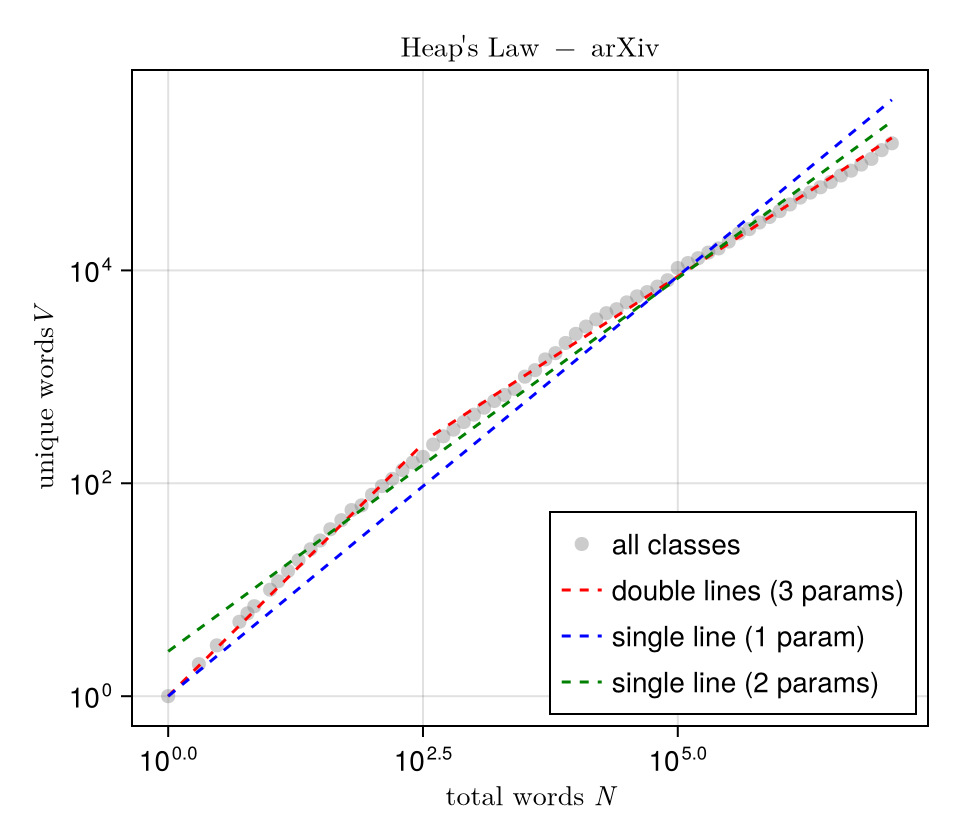

In [9]:
fig = Figure(size=(320*1.5, 280*1.5))
ax = Axis(
    fig[1,1],
    xscale=log10, yscale=log10,
    title=L"\text{Heap's Law - arXiv}",
    xlabel=L"\text{total words } N",
    ylabel=L"\text{unique words} V"
)

# Base scatter
x, y = collect(keys(heap_dict_total)), collect(values(heap_dict_total))
scatter!(ax, x, y, color=(0.5, 0.5, 0.5, 0.4), markersize=10, label="all classes")

lines!(ax, x[x .< out.xb], exp.(model1(log.(x[x .< out.xb]), out.p1)), color=:red, linestyle=:dash, label="double lines (3 params)")
lines!(ax, x[x .>= out.xb], exp.(model2(log.(x[x .>= out.xb]), out.p2)), color=:red, linestyle=:dash)
lines!(ax, x, exp.(model1(log.(x), fit1.param)), color=:blue, linestyle=:dash, label="single line (1 param)")
lines!(ax, x, exp.(model2(log.(x), fit2.param)), color=:green, linestyle=:dash, label="single line (2 params)")

axislegend(ax, position=:rb, framevisible=true)

fig

In [38]:
params_dict = Dict()
for (d, dict) in heap_dict_domains
    x, y = collect(keys(dict)), collect(values(dict))
    params_dict[d] = find_breakpoint(x, y, scanrange=collect(50:5:1500))
    println(d)
    println(params_dict[d])
end

physics
(xb = 160, p1 = [0.9649776433815446], p2 = [1.6223573831804876, 0.6520479451494489], res = 0.7045598049323842)
8.018997003902244e-5   1995262
math
(xb = 255, p1 = [0.9425836952551476], p2 = [2.048455223933086, 0.5803991216580516], res = 0.27597431108288495)
0.00020255376610997479   1258925
astro-ph
(xb = 400, p1 = [0.9496445465646742], p2 = [2.2105111871345793, 0.5859534126233127], res = 0.739871582036057)
0.00010047547506688527   3981071
q-bio
(xb = 1260, p1 = [0.8863874310715353], p2 = [2.0897492061543916, 0.6043641140730872], res = 0.5972039947900438)
0.0005016151210683925   2511886
cond-mat
(xb = 400, p1 = [0.9489317843040588], p2 = [2.3746595380622626, 0.561394029467017], res = 0.40916435593858547)
0.00015924289557726743   2511886


### HYP3: The distribution of document sizes is heavy-tailed but with an upper cutoff
Not sure on the relevance of this. Supposition: this distribution introduces some sort of cutoff which yeald the AFD to be a Tweedie distribution for which TL is guaranteed

### HYP4: Taylor's law is satisfied for components within a set of documents
Similarly to Heap's law, TL is found to hold in most complex systems. But is it holding because of HYP1 and/or HYP2? Or is it uncorrelated from them? Also, TL is a very robust pattern and it may indicate that the AFD is a Tweedie distribution, although it is not guaranteed.

### HYP5: AFD (for a single species) follows a distribution in the Pareto family
The idea is that between some lower and upper thresholds, all species follow the same type of distribution

### HYP6: Aggregated AFD is of the same family of the single species AFD
This is true only if the shape parameters of the single species AFD are very similar, if not the same.